In [1]:
%load_ext autoreload
%autoreload 2

In [16]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob
from time import time
import os
from dataclasses import replace
from RaTag.core.datatypes import Run, SetPmt, S2Areas, Waveform
from RaTag.core.config import TimingConfig, IntegrationConfig, FitConfig
from RaTag.core.wfm2read_fast import wfm2read
from RaTag.core.paths import get_output_root
from RaTag.waveform.preprocessing import subtract_pedestal, moving_average, threshold_clip
from RaTag.io.bootstrap import bootstrap_from_config
from RaTag.thgem_tpc.drift_workflow import map_drift_physics
from RaTag.el_tpc.timing_workflow import (map_time_windows, resolve_set_timing,
                                           map_timing_plots, find_s1, find_s2)
from RaTag.thgem_tpc.recoil_workflow import (map_recoil_integration, resolve_set_recoils,
                                             _check_s2_clipping, _check_area_bounds,
                                            _integrate_s2_areas, _find_left_boundary)
from RaTag.io.file_ops import load_yaml, iter_waveforms
from RaTag.io import file_ops
from RaTag.plotting import plot_timing_histograms, plot_waveform

from scipy.ndimage import maximum_filter1d
%matplotlib inline

In [3]:
config_path = '/Users/pabloherrero/sabat/RaTagging/configs/recoils/run43_analysis.yaml'
config = load_yaml(config_path)
time_config_dict = config['preparation']
time_config = TimingConfig(**time_config_dict)

run = bootstrap_from_config(config_path)
run = map_drift_physics(run)

Found 9 directories in RUN43_EL25kVcm
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0120_Anode1120 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0188_Anode1188 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0288_Anode1288 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0480_Anode1480 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0576_Anode1576 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0672_Anode1672 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0768_Anode1768 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0864_Anode1864 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0960_Anode1960 with 200 waveforms.
  → Bootstrapped 9 PMT Sets and 9 Alpha Sets. (Multi-Isotope: True)


In [4]:
set0 = run.sets[1]
set6 = run.sets[6]

In [5]:
set0 = resolve_set_recoils(set0, max_frames=None, config=time_config, force=True)

  Iterating FieldScan_Gate0188_Anode1188: 200/200 (100.0%) | ETA: 00:00   
  ✓ FieldScan_Gate0188_Anode1188: Computed 'n_areas_recoil' and stored metadata


In [6]:
set6 = resolve_set_recoils(set6, max_frames=None, config=time_config, force=True)

  Iterating FieldScan_Gate0768_Anode1768: 200/200 (100.0%) | ETA: 00:00   
  ✓ FieldScan_Gate0768_Anode1768: Computed 'n_areas_recoil' and stored metadata


  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0188_Anode1188_s2_areas.npz


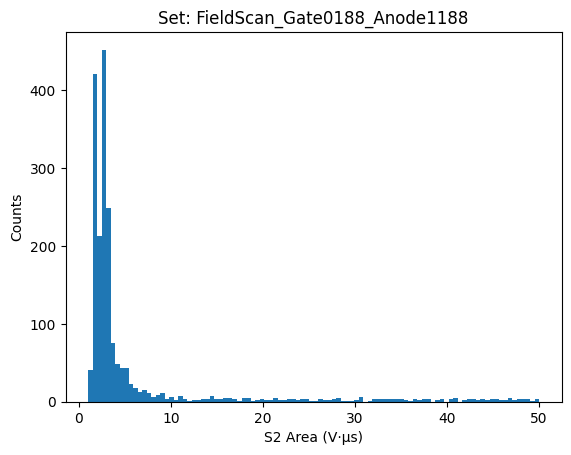

In [7]:
file = file_ops.load_npz_arrays(set0, signal_type='s2_areas', )
# stats_dict = file['stats']
s2_areas_hard = file['s2_areas']
# print(stats_dict)
plt.hist(s2_areas_hard, bins=100, range=(1, 50));
plt.gca().set(xlabel='S2 Area (V·µs)', ylabel='Counts', title='Set: {}'.format(set0.name));

In [9]:
file = file_ops.load_npz_arrays(set0, signal_type='s2_areas', )
# stats_dict = file['stats']
s2_areas = file['s2_areas']
# # print(stats_dict)
# plt.hist(s2_areas, bins=100, range=(1, 50));
# plt.gca().set(xlabel='S2 Area (V·µs)', ylabel='Counts', title='Set: {}'.format(set0.name));
s2_areas

  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0188_Anode1188_s2_areas.npz


array([10.86150763, 20.34411921,  1.92586808, ...,  2.15672649,
        5.51777662,  3.77725215])

  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0768_Anode1768_s2_areas.npz


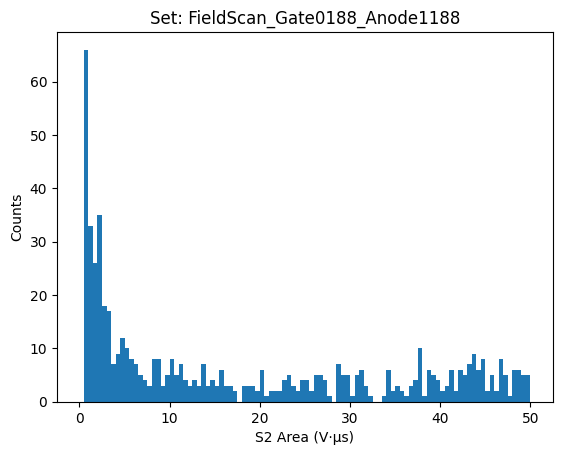

In [8]:
file = file_ops.load_npz_arrays(set6, signal_type='s2_areas', )
# stats_dict = file['stats']
s2_areas_hard = file['s2_areas']
# print(stats_dict)
n, bins, patches = plt.hist(s2_areas_hard, bins=100, range=(0, 50));
plt.gca().set(xlabel='S2 Area (V·µs)', ylabel='Counts', title='S2 Area Distribution (Only clip and area Cuts)');
plt.gca().set(xlabel='S2 Area (V·µs)', ylabel='Counts', title='Set: {}'.format(set0.name));


In [22]:
n.sum() / len(s2_areas_hard)

np.float64(0.5214690982776089)

In [24]:
n.sum() / len(s2_areas_hard)

np.float64(0.9256940222897669)

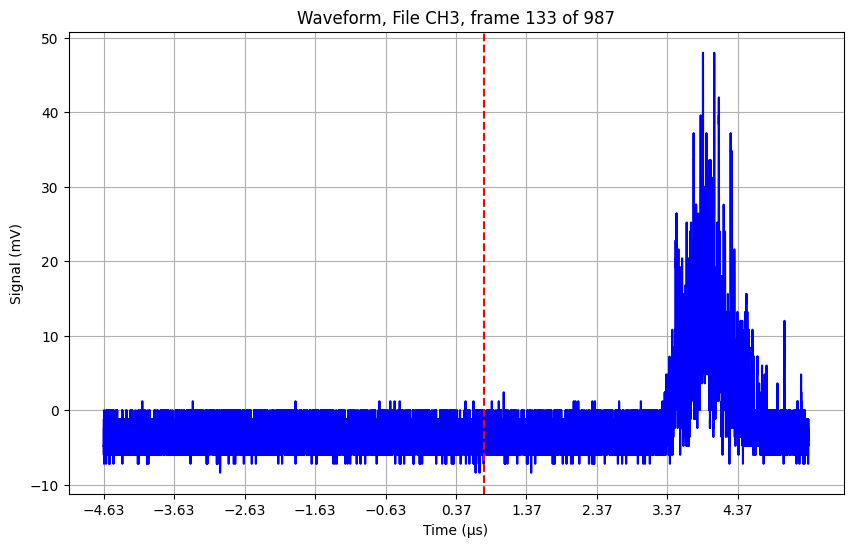

In [468]:
t_s2_min = -1.5 + set0.time_drift * time_config.s2_margin
frame_idx += 1
# wf = next(iter_waveforms(set0, max_files=1, show_progress=True))
plot_waveform(wf, frame=frame_idx)
plt.axvline(t_s2_min, color='r', linestyle='--', label='S2 Min Time')

In [293]:
time_config.s2_v_min

5.0

In [418]:
time_config = replace(time_config, s2_v_min=15)

In [183]:
def _check_s2_clipping(v_window: np.ndarray, max_v: float) -> np.ndarray:
    """Anti-alpha cut: Returns 1D boolean mask of frames avoiding amplifier saturation."""
    return np.max(v_window, axis=1) < max_v

def _find_left_boundary(v_sliced: np.ndarray, t_sliced: np.ndarray, peak_idx: np.ndarray, 
                        peak_heights: np.ndarray, peak_times: np.ndarray, 
                        fraction_left: float, fallback_window: float) -> tuple[np.ndarray, np.ndarray]:
    """Vectorized search for the left boundary crossing with static fallback."""
    dynamic_thresh_left = (peak_heights * fraction_left)[:, np.newaxis]
    below_thresh_left = v_sliced <= dynamic_thresh_left
    idx_2d = np.arange(v_sliced.shape[1])[np.newaxis, :]

    left_mask = idx_2d <= peak_idx[:, np.newaxis]
    valid_left = below_thresh_left & left_mask
    first_below_left_rev = np.argmax(np.fliplr(valid_left), axis=1)
    
    has_valid_left = np.any(valid_left, axis=1)
    
    start_times = np.where(has_valid_left,
                           t_sliced[np.clip(v_sliced.shape[1] - 1 - first_below_left_rev, 0, v_sliced.shape[1] - 1)],
                           peak_times - fallback_window)

    return start_times, has_valid_left

def _find_right_boundary(v_sliced: np.ndarray, t_sliced: np.ndarray, peak_idx: np.ndarray, 
                         peak_heights: np.ndarray, peak_times: np.ndarray, 
                         fraction_right: float, fallback_window: float) -> tuple[np.ndarray, np.ndarray]:
    """Vectorized search for the right boundary crossing with static fallback."""
    dynamic_thresh_right = (peak_heights * fraction_right)[:, np.newaxis]
    below_thresh_right = v_sliced <= dynamic_thresh_right
    idx_2d = np.arange(v_sliced.shape[1])[np.newaxis, :]

    right_mask = idx_2d >= peak_idx[:, np.newaxis]
    valid_right = below_thresh_right & right_mask
    last_below_right = np.argmax(valid_right, axis=1)

    has_valid_right = np.any(valid_right, axis=1)

    end_times = np.where(has_valid_right,
                         t_sliced[np.clip(last_below_right - 1, 0, v_sliced.shape[1] - 1)],
                         peak_times + fallback_window)

    return end_times, has_valid_right

def _check_area_bounds(areas: np.ndarray, min_area: float, max_area: float) -> np.ndarray:
    """Returns 1D boolean mask of frames passing the area thresholds."""
    return (areas > min_area) & (areas < max_area)

In [188]:
time_config.s2_fraction_right

0.01

In [486]:
def find_s2(wf: Waveform, config: TimingConfig, t_start_delay: float = 0.0) -> dict:
    """
    Vectorized engine for S2 detection. 
    Maintains strict array alignment and tracks all diagnostic states.
    """
    stats = {
        'total': wf.nframes, 'pass_clip': 0, 'pass_left': 0, 'pass_right': 0, 
        'pass_v_min': 0, 'fallback_left': 0, 'fallback_right': 0, 'accepted': 0
    }

    # 1. Physics Preprocessing
    # wf_clipped = threshold_clip(wf_sub, threshold=config.bs_threshold) # Used strictly for area integration
    
    # Smooth envelope used strictly for boundary search
    # v_envelope = maximum_filter1d(wf_sub.v, size=config.s2_window_ma, axis=1)
    wf_smooth = moving_average(wf, window=config.s2_window_ma)
    wf_sub = subtract_pedestal(wf_smooth, n_points=config.n_pedestal)

    mask = wf_smooth.t > config.s2_start_min
    t_sliced = wf_smooth.t[mask]
    v_sliced = wf_smooth.v[:, mask] if wf_smooth.ff else wf_smooth.v[mask][np.newaxis, :]

    if not np.any(mask) or v_sliced.shape[1] == 0:
        return {'s2_areas': np.array([]), 'uids': np.array([]), 'n_accepted': 0, 'stats': stats}

    # 2. Extract Global Peaks
    peak_idx = np.argmax(v_sliced, axis=1)
    peak_heights = v_sliced[np.arange(len(v_sliced)), peak_idx]
    peak_times = t_sliced[peak_idx]

    # 3. Apply Decoupled Vectorized Cuts
    pass_clip = _check_s2_clipping(wf.v, config.s2_threshold) # Evaluated on RAW waveform

    pass_v_min = peak_heights > config.s2_v_min
    start_times, pass_left = _find_left_boundary(
        v_sliced, t_sliced, peak_idx, peak_heights, peak_times, 
        config.s2_fraction_left, config.s2_fallback_window_left
    )
    
    end_times, pass_right = _find_right_boundary(
        v_sliced, t_sliced, peak_idx, peak_heights, peak_times, 
        config.s2_fraction_right, config.s2_fallback_window
    )

    # 4. Area Integration (Executed on the threshold-clipped waveform)
    dt = wf_sub.t[1] - wf_sub.t[0]
    t_2d = wf_sub.t[np.newaxis, :]
    s2_mask = (t_2d >= start_times[:, np.newaxis] + t_start_delay) & (t_2d <= end_times[:, np.newaxis])
    s2_areas = np.sum(wf_sub.v * s2_mask, axis=1) * dt

    pass_area = _check_area_bounds(s2_areas, config.s2_min_area, config.s2_max_area)

    # 5. Compile Final Acceptance (Boundaries bypassed entirely due to fallbacks)
    final_mask = pass_clip & pass_area & pass_v_min

    # 6. Extract Diagnostic N-1 UIDs (Frames that failed ONLY the area cut)
    strict_area_failure = pass_clip & pass_left & pass_right & (~pass_area)
    n_minus_one_uids = wf.uids[strict_area_failure] if np.sum(strict_area_failure) > 0 else np.array([])

    # 7. Update Stats Ledger
    stats['pass_clip'] += int(pass_clip.sum())
    stats['pass_left'] += int(pass_left.sum())
    stats['pass_right'] += int(pass_right.sum())
    stats['pass_v_min'] += int(pass_v_min.sum())
    stats['fallback_left'] += int((~pass_left & pass_clip).sum())
    stats['fallback_right'] += int((~pass_right & pass_clip).sum())
    stats['accepted'] += int(final_mask.sum())

    # 8. Return Strictly Aligned Output
    return {
        's2_areas': np.atleast_1d(s2_areas[final_mask]) if np.sum(final_mask) > 0 else np.array([]),
        'raw_areas': np.atleast_1d(s2_areas),
        'peak_times': np.atleast_1d(peak_times[final_mask]) if np.sum(final_mask) > 0 else np.array([]),
        'start_times': np.atleast_1d(start_times[final_mask]) if np.sum(final_mask) > 0 else np.array([]),
        'end_times': np.atleast_1d(end_times[final_mask]) if np.sum(final_mask) > 0 else np.array([]),
        'uids': np.atleast_1d(wf.uids[final_mask]) if np.sum(final_mask) > 0 else np.array([]),
        'n_minus_one_uids': np.atleast_1d(n_minus_one_uids),
        'n_accepted': int(np.sum(final_mask)),
        'stats': stats
    }

In [ ]:
def plot_s2_diagnostic(wf, s2_results: dict, config, frame_idx: int) -> None:
    """
    Pure plotting function for S2 boundary diagnostics.
    Visualizes a single frame against explicit physical thresholds and computed area.
    WARNING: Now explicitly applies pedestal subtraction to match the physics engine.
    """
    # 1. Physics Preprocessing (Mirroring the engine exactly)
    wf_smooth = moving_average(wf, window=config.s2_window_ma)
    wf_sub = subtract_pedestal(wf_smooth, n_points=config.n_pedestal)
    
    # 2. Extract physical frame
    v_frame = wf_sub.v[frame_idx] if wf_sub.ff else wf_sub.v
    t_frame = wf_sub.t
    frame_uid = wf_sub.uids[frame_idx]
    
    frame_area = s2_results.get('raw_areas', np.zeros(wf.nframes))[frame_idx]
    
    # 3. Determine Audit Status
    is_accepted = frame_uid in s2_results.get('uids', np.array([]))
    is_n_minus_one = frame_uid in s2_results.get('n_minus_one_uids', np.array([]))
    
    if is_accepted:
        status = "ACCEPTED"
        plot_color = 'green'
    elif is_n_minus_one:
        status = "REJECTED (Failed Area Cut ONLY)"
        plot_color = 'orange'
    else:
        status = "REJECTED (Failed Boundary/Clip/V_min)"
        plot_color = 'crimson'
        
    # 4. Visual Overlays
    v_smooth = wf_sub.v[frame_idx] if wf_sub.ff else wf_sub.v
    
    search_mask = t_frame > config.s2_start_min
    valid_v = v_smooth[search_mask] if np.any(search_mask) else v_smooth
    peak_val = np.max(valid_v)
    
    thresh_left = peak_val * config.s2_fraction_left
    thresh_right = peak_val * config.s2_fraction_right
    
    # 5. Render
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(t_frame, v_frame, label='Subtracted Waveform', color='blue', alpha=0.6)
    ax.plot(t_frame, v_smooth, label=f'Smoothed (MA: {config.s2_window_ma})', color='black', linewidth=1.5)
    
    # Explicit Physics Boundaries
    ax.axvline(config.s2_start_min, color='purple', linestyle=':', label='s2_start_min')
    ax.axhline(config.s2_v_min, color='goldenrod', linestyle='-.', label=f'V_min Cut ({config.s2_v_min} mV)')
    ax.axhline(thresh_left, color='green', linestyle='--', label=f'Left Thresh ({config.s2_fraction_left*100}%)')
    ax.axhline(thresh_right, color='red', linestyle='--', label=f'Right Thresh ({config.s2_fraction_right*100}%)')
    
    if is_accepted:
        try:
            idx = np.where(s2_results['uids'] == frame_uid)[0][0]
            ax.axvspan(s2_results['start_times'][idx], 
                       s2_results['end_times'][idx], 
                       color='green', alpha=0.2, label='Integration Window')
        except IndexError:
            pass
            
    ax.set_title(f"UID: {frame_uid} | Status: {status}\nComputed Area: {frame_area:.3f} mV·µs", 
                 color=plot_color, fontweight='bold')
                 
    ax.set_xlabel("Time (µs)")
    ax.set_ylabel("Amplitude (mV) [Pedestal Subtracted]")
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

In [181]:
frame_idx = 0

In [483]:
file_idx = 0
wf = next(iter_waveforms(set0, max_files=1, show_progress=True))

In [386]:
def_idx = 0

In [398]:
frame

np.int64(163)

np.float64(1.1757444467171434)

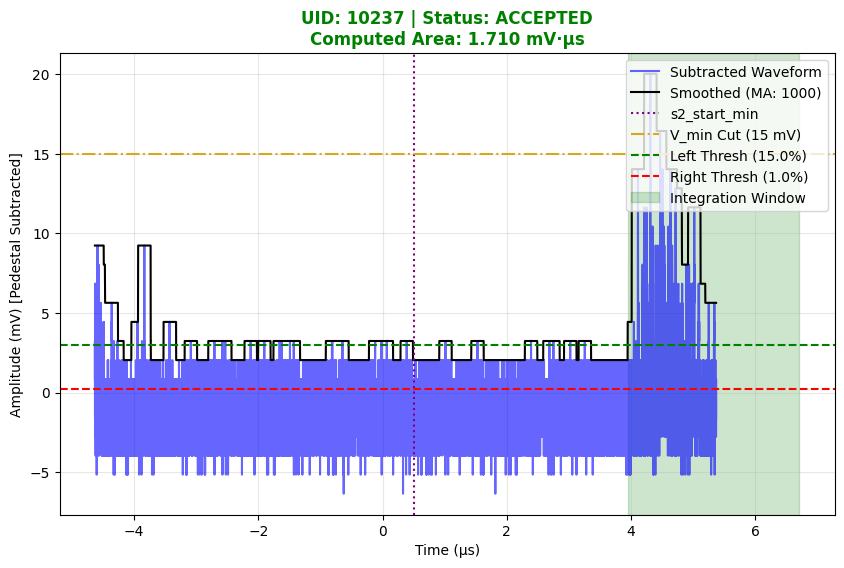

In [412]:
from RaTag.io.file_ops import load_waveform_by_uid

def_idx += 1
wf, frame = load_waveform_by_uid(set0, defective_uids[def_idx])
plot_s2_diagnostic(wf, s2_results, time_config, frame)
s2_areas[93]

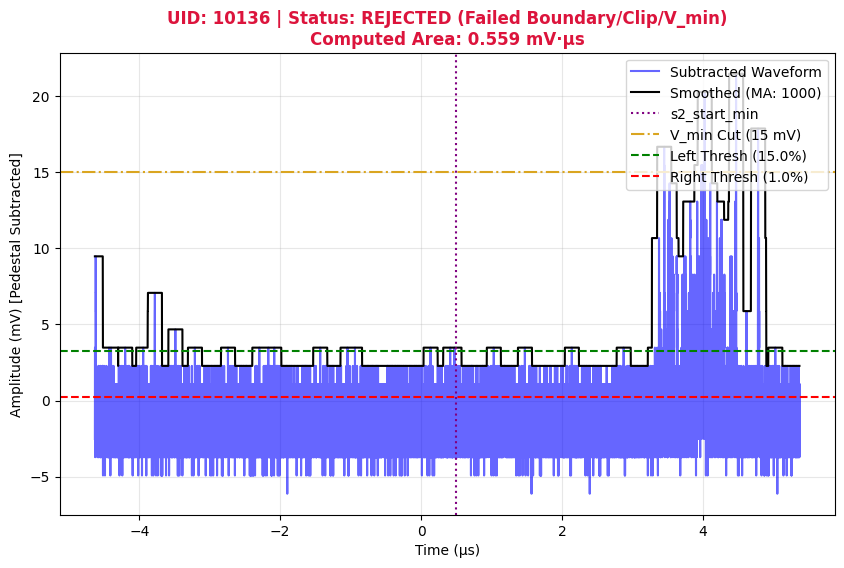

In [487]:
frame_idx += 1
s2_results = find_s2(wf, time_config, )

# 2. Pure Visualization

plot_s2_diagnostic(wf, s2_results, time_config, frame_idx)

In [479]:
wf_av = moving_average(wf, window=1500)
wf_sub = subtract_pedestal(wf_av, n_points=time_config.n_pedestal)
time_config.s2_window_ma

1000

(<Axes: title={'center': 'Waveform, File CH3, frame 133 of 987'}, xlabel='Time (µs)', ylabel='Signal (mV)'>,
 np.float64(18.755636745282015))

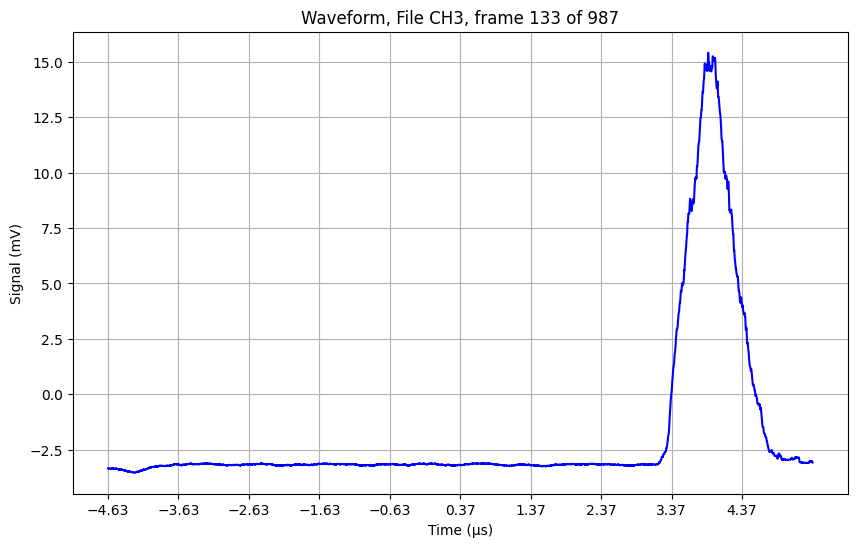

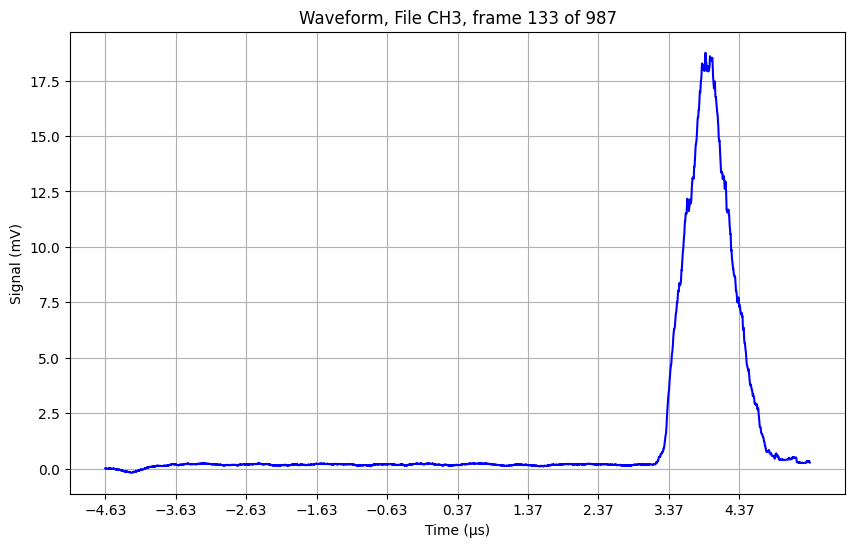

In [480]:
plot_waveform(wf_av, frame=frame_idx)
plot_waveform(wf_sub, frame=frame_idx)

In [421]:
len(s2_results['uids']), len(s2_results['s2_areas']), len(s2_results['n_minus_one_uids']), s2_results['n_accepted'], s2_results['stats']

(348,
 348,
 65,
 348,
 {'total': 987,
  'pass_clip': 952,
  'pass_left': 435,
  'pass_right': 81,
  'pass_v_min': 398,
  'fallback_left': 542,
  'fallback_right': 879,
  'accepted': 348})

In [424]:
1- s2_results['stats']['pass_v_min'] / s2_results['stats']['total']

0.5967578520770009

In [241]:
s2_results.keys()

dict_keys(['s2_areas', 'peak_times', 'start_times', 'end_times', 'uids', 'n_minus_one_uids', 'n_accepted', 'stats'])

In [ ]:
uids = s2_results['uids']
s2_areas = s2_results['s2_areas']
np.where(s2_areas < 2)[0], uids[np.where(s2_areas < 2)[0]], 
defective_uids = uids[np.where(s2_areas < 2)[0]]


np.int64(10016)

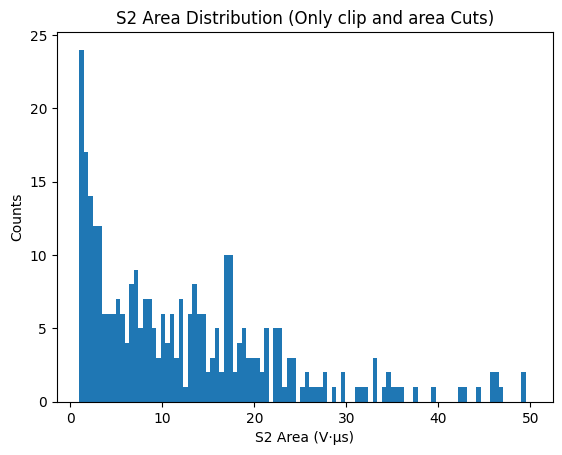

In [422]:
n, bins, patches = plt.hist(s2_results['s2_areas'], bins=100, range=(1, 50));
plt.gca().set(xlabel='S2 Area (V·µs)', ylabel='Counts', title='S2 Area Distribution (Only clip and area Cuts)');

In [331]:
n[0] + n[1], np.sum(n[2:])

(np.float64(223.0), np.float64(297.0))

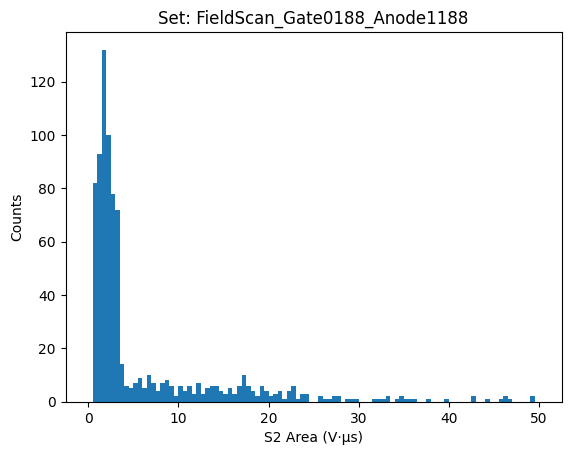

In [179]:
plt.hist(s2_areas, bins=100, range=(0, 50), )
plt.gca().set(ylabel='Counts', xlabel='S2 Area (V·µs)', title='Set: {}'.format(set0.name));